# 06. The Baseline That Must Be Beaten

**The question.** How strong is a genuinely well-tuned classical baseline? Every embedding
claim this lab will ever make is relative to Fellegi–Sunter, and the literature's answer is
compromised in both directions: embedding papers routinely compare against a *lazy* FS
(default comparators, no term-frequency adjustment, untuned priors), while the strong FS
numbers in circulation are maintainer-sourced — Splink's own documentation benchmarking
Splink (`notes/lit_review.md` flags exactly this bias rail for BAS-01). Neither is evidence.
This notebook builds the tuned baseline ourselves — EM-fitted m/u weights, Jaro–Winkler-
binned name comparators, term-frequency adjustment — and measures it under the lab's own
protocol: the calibrated corpus (notebook 05), entity-disjoint splits (MET-07), entity-level
metrics with entity-unit BCa intervals (MET-01/03), and the locked operating points, never
best-F1 (MET-02).

**What this notebook settles.** Four things: (1) the tuned FS fit itself, with its EM
convergence record and learned evidence weights *displayed*, not asserted — plus a two-fit
ablation showing what the TF adjustment specifically buys on query-picked probe pairs;
(2) one blocking for every arm — deterministic matchkey candidates on the eval split, with
pair-completeness measured and an oracle ceiling computed (what a *perfect* scorer could
extract from these candidates); (3) `bas01_scored_pairs` — the FS match probabilities on
exactly those candidates, the contract artifact notebook 07 consumes; (4) the headline
`bas01_fs_baseline`: system × operating-point rows (fixed precision {0.99, 0.995}, the
{1:1, 10:1, 100:1} cost grid, fixed FP budgets) with B-cubed metrics and entity-unit BCa
CIs — including notebook 00's naive JW-mean quickstart scorer re-run on THIS corpus under
THIS protocol as the honest same-corpus contrast.

In [1]:
import functools
import logging
import time

import jellyfish
import numpy as np
import pandas as pd
from IPython.display import display

from er_lab.blocking import matchkeys
from er_lab.cluster.schemes import transitive_closure
from er_lab.config import REPO_ROOT, config_hash, load_config_from_env, set_all_seeds
from er_lab.data.schema import DeclaredSchema
from er_lab.eval.bootstrap import bootstrap_ci
from er_lab.eval.metrics import bcubed, blocking_metrics
from er_lab.eval.operating_points import (
    cost_optimal_threshold,
    find_threshold_for_precision,
    fp_budget_threshold,
)
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box
from er_lab.score import fs as fs_mod
from er_lab.score.fs import fit_fs, fs_scores

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v22-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants

The corpus size is fixed upstream (whatever `calibrated_corpus` holds at this tier), so the
dials here are protocol budgets: threshold-grid resolution for the operating-point sweeps,
bootstrap replicates, Splink's u-estimation sampling budget, and the probe-set size for the
TF ablation. Operating points themselves are the PLAN §5 lock — precision targets, cost
grid, FP budgets — identical at every tier. Smoke budget for this whole notebook:
**<= ~20 min on the 4-CPU container** (wall-clock printed and measured at the end).

In [3]:
TIER = str(cfg.run.tier)
GRID = {"smoke": 80, "mid": 150, "target": 200, "analytical": 80}[TIER]
N_BOOT = {"smoke": 500, "mid": 1000, "target": 2000, "analytical": 500}[TIER]
MAX_PAIRS_U = {"smoke": 1e6, "mid": 1e7, "target": 1e8, "analytical": 1e6}[TIER]
PROBE_N = {"smoke": 400, "mid": 2000, "target": 4000, "analytical": 400}[TIER]
PREC_TARGETS = (0.99, 0.995)  # PLAN §5 fixed entity-precision operating points
COST_GRID = ((1, 1), (10, 1), (100, 1))  # (fp_cost, fn_cost) — FP:FN 1:1 / 10:1 / 100:1
BUDGETS = (1.0, 2.0, 4.0)  # accepted pairs per record (fixed-FP-budget secondary protocol)
RARE_MAX = 4  # probe stratum: a surname with <= this many carriers counts as rare
PRIMARY_SEED = int(cfg.run.seed)
print(f"tier={TIER}: grid={GRID}, n_boot={N_BOOT}, u-sampling max_pairs={MAX_PAIRS_U:.0e}, "
      f"probe n/stratum={PROBE_N}; smoke budget <= ~20 min")

tier=smoke: grid=80, n_boot=500, u-sampling max_pairs=1e+06, probe n/stratum=400; smoke budget <= ~20 min


## 1. The arena: whose records, whose boundaries?

Everything is loaded through the registry at this run's tier — the calibrated corpus with
its measured channel rates, and the MET-07 splits. The baseline trains on the
**entity-disjoint train half** and is evaluated on the **entity-disjoint eval half**: no
entity contributes records to both sides (PLAN §5), so nothing the EM fit absorbs about a
person can flatter that same person's evaluation. Governance note: name and place strings
display verbatim throughout this notebook because the corpus is `historical_50k` (public
Wikidata historical figures, error-injected). **No NC person-level value appears anywhere
here** — the only NC-derived inputs are the aggregate rate tables already baked into the
corpus's provenance upstream (DATA_GOVERNANCE.md).

In [4]:
corpus, corpus_meta = registry.load("calibrated_corpus", tier=cfg.run.tier)
splits, splits_meta = registry.load("met07_splits", tier=cfg.run.tier)
CORPUS_PROVENANCE = (
    f"calibrated_corpus run {corpus_meta['created_at']} (cfg {corpus_meta['config_hash']}, "
    f"tier {corpus_meta['tier']}, seed {corpus_meta['extra']['seed']})"
)
print(f"corpus: {CORPUS_PROVENANCE}")
print(f"  {len(corpus):,} records, {corpus['entity_id'].nunique():,} entities, "
      f"{corpus['household_id'].nunique():,} households")

SCHEME = "entity_disjoint"
train_ids = set(splits["schemes"][SCHEME]["train"])
eval_ids = set(splits["schemes"][SCHEME]["eval"])
checks = splits["metadata"]["checks"][SCHEME]
train = corpus[corpus["record_id"].isin(train_ids)].reset_index(drop=True)
ev = corpus[corpus["record_id"].isin(eval_ids)].reset_index(drop=True)
truth_ev = ev.set_index("record_id")["entity_id"]
records_ev = pd.Index(truth_ev.index)
schema = DeclaredSchema.from_yaml(REPO_ROOT / str(cfg.data.schema))
print(f"split scheme: {SCHEME} (split seed {splits['metadata']['seed']}, "
      f"entities straddling the boundary: {checks['entities_straddling']})")
print(f"  train: {len(train):,} records / {train['entity_id'].nunique():,} entities")
print(f"  eval : {len(ev):,} records / {truth_ev.nunique():,} entities")

corpus: calibrated_corpus run 2026-08-29T15:42:13.364770+00:00 (cfg 129c9d9243ca, tier smoke, seed 17)
  32,259 records, 2,507 entities, 1,858 households
split scheme: entity_disjoint (split seed 17, entities straddling the boundary: 0)
  train: 16,164 records / 1,252 entities
  eval : 16,095 records / 1,255 entities


## 2. The conjecture, before the fit

Pre-registered before any model exists. The headline prediction deliberately states the
folklore number this baseline is reputed to hit — the lit-review rail is that such numbers
are maintainer-sourced, so here the lab measures it under its own protocol and lets the
verdict fall where the data puts it. The comparison rule per operating point is fixed now:
higher B-cubed recall at the fixed-precision points, lower total pair cost on the cost
grid, higher B-cubed F at matched FP budget.

In [5]:
_ = conjecture_card(
    card_id="BAS-01",
    conjecture=(
        "A genuinely well-tuned Fellegi-Sunter baseline (EM-fitted m/u, term-frequency "
        "adjustment, Jaro-Winkler-binned name comparators) is the strong classical bar on "
        "the calibrated corpus: measured under the lab's own protocol it reaches the "
        "folklore-grade quality its maintainers report, and it dominates the naive "
        "quickstart scorer at every locked operating point."
    ),
    pressure=(
        "model family, with blocking and protocol held fixed: tuned Splink FS "
        "(score.fs.fit_fs on the entity-disjoint train half; TF-adjusted, JW-binned, "
        "EM-trained) vs notebook 00's untrained mean-Jaro-Winkler quickstart scorer, both "
        "scoring the SAME matchkey candidate pairs on the SAME eval half"
    ),
    property=(
        "not an embedding property (no embedding exists yet): the measured mediators are "
        "(a) the EM-learned evidence weights log2(m/u) per comparison level, (b) the TF "
        "discount on shared-common-surname agreement, isolated by a two-fit ablation on a "
        "query-picked probe set, and (c) blocking pair-completeness with its oracle "
        "ceiling, which upper-bounds what ANY scorer can extract from the candidates"
    ),
    metric=(
        "B-cubed precision/recall/F on the entity-disjoint eval split with entity-unit BCa "
        "95% CIs, at the locked operating points: fixed entity-precision {0.99, 0.995}, "
        "cost grid FP:FN {1:1, 10:1, 100:1}, FP budgets {1, 2, 4} pairs/record "
        "(never per-method best-F1, per MET-02) — registered in bas01_fs_baseline"
    ),
    prediction=(
        "P1 (machinery): both EM sessions converge; learned weights are sane (every "
        "exact-match level carries positive log2(m/u), every all-other level negative); "
        "the TF fit scores common-surname agreement lower than its no-TF twin while rare-"
        "surname agreement is not discounted. P2 (the folklore number, measured): tuned FS "
        "attains the 0.99 entity-precision point AND reaches B-cubed F >= 0.90 there. "
        "P3 (dominance): FS beats the JW-mean quickstart at EVERY locked operating point "
        "under the comparison rule above. Pre-flagged risks: on a smoke-sized eval half "
        "the 0.995 target may be unattainable (the fallback rail fires loudly, PLAN §5); "
        "and if blocking pair-completeness caps the candidate set well below the truth, "
        "P2 can fail for reasons no scorer can fix — the oracle ceiling is computed "
        "precisely to attribute any such failure."
    ),
    registry=registry,
)

### Conjecture card `BAS-01`

| | |
|---|---|
| **Conjecture** | A genuinely well-tuned Fellegi-Sunter baseline (EM-fitted m/u, term-frequency adjustment, Jaro-Winkler-binned name comparators) is the strong classical bar on the calibrated corpus: measured under the lab's own protocol it reaches the folklore-grade quality its maintainers report, and it dominates the naive quickstart scorer at every locked operating point. |
| **Pressure (dial)** | model family, with blocking and protocol held fixed: tuned Splink FS (score.fs.fit_fs on the entity-disjoint train half; TF-adjusted, JW-binned, EM-trained) vs notebook 00's untrained mean-Jaro-Winkler quickstart scorer, both scoring the SAME matchkey candidate pairs on the SAME eval half |
| **Embedding property** | not an embedding property (no embedding exists yet): the measured mediators are (a) the EM-learned evidence weights log2(m/u) per comparison level, (b) the TF discount on shared-common-surname agreement, isolated by a two-fit ablation on a query-picked probe set, and (c) blocking pair-completeness with its oracle ceiling, which upper-bounds what ANY scorer can extract from the candidates |
| **System metric** | B-cubed precision/recall/F on the entity-disjoint eval split with entity-unit BCa 95% CIs, at the locked operating points: fixed entity-precision {0.99, 0.995}, cost grid FP:FN {1:1, 10:1, 100:1}, FP budgets {1, 2, 4} pairs/record (never per-method best-F1, per MET-02) — registered in bas01_fs_baseline |
| **Pre-registered prediction** | P1 (machinery): both EM sessions converge; learned weights are sane (every exact-match level carries positive log2(m/u), every all-other level negative); the TF fit scores common-surname agreement lower than its no-TF twin while rare-surname agreement is not discounted. P2 (the folklore number, measured): tuned FS attains the 0.99 entity-precision point AND reaches B-cubed F >= 0.90 there. P3 (dominance): FS beats the JW-mean quickstart at EVERY locked operating point under the comparison rule above. Pre-flagged risks: on a smoke-sized eval half the 0.995 target may be unattainable (the fallback rail fires loudly, PLAN §5); and if blocking pair-completeness caps the candidate set well below the truth, P2 can fail for reasons no scorer can fix — the oracle ceiling is computed precisely to attribute any such failure. |

*Immutable — sha256 `2475eb94dcf7`; registered before the affected runs, never edited (PLAN §5).*


## 3. What does "well-tuned" actually buy?

The fit is `er_lab.score.fs.fit_fs` — the package's one tuned recipe, deterministic end to
end: JW-binned `NameComparison`s on the name fields (exact / >=0.92 / >=0.88 / >=0.70 /
else) with TF adjustment on exact name agreement, Levenshtein-binned dob/zip, a prior from
an AND-rule over the two strongest keys, u by seeded random sampling, and two
complementary EM sessions (block on dob to train the name m's, block on names to train the
rest — EM cannot estimate a comparison that sits in its own blocking rule). Splink's
per-iteration INFO stream is silenced below — the level must be pinned on the
`splink.internals` child logger, because every `Linker` construction resets the parent
`splink` logger back to INFO — and its default-`max_pairs` warning is filtered as
misleading here: Splink emits it whenever `max_pairs == 1e6` whether or not the caller
passed it, and `MAX_PAIRS_U = 1e6` IS passed explicitly (the smoke-tier budget above).
Convergence is *asserted on the recorded facts* in `linker._er_lab_training`, displayed
below — the fs-adapter's own honesty rail.

In [6]:
# Convergence facts, not log lines. All of Splink 4's emitting loggers live under
# splink.internals.*; Linker.__init__ resets logging.getLogger("splink") to INFO on every
# construction but never touches this child, so the pin holds for the whole notebook.
logging.getLogger("splink.internals").setLevel(logging.WARNING)


class _MaxPairsDefaultFilter(logging.Filter):
    """Drop Splink's 'default value for max_pairs' warning: it fires on the VALUE
    (max_pairs == 1e6), not on whether the caller passed it — and MAX_PAIRS_U is
    passed explicitly here, so the warning would misreport this notebook's config."""

    def filter(self, record: logging.LogRecord) -> bool:
        return "default value for `max_pairs`" not in record.getMessage()


logging.getLogger("splink.internals.linker_components.training").addFilter(
    _MaxPairsDefaultFilter()
)

t0 = time.time()
linker = fit_fs(train, schema=schema, max_pairs=MAX_PAIRS_U)
FIT_SECS = time.time() - t0
em_tbl = pd.DataFrame(linker._er_lab_training["em_sessions"])
model_tf = linker.misc.save_model_to_json()
print(f"fit_fs on the train half ({len(train):,} records): {FIT_SECS:.1f}s; "
      f"roles used: {linker._er_lab_training['roles']}")
print(f"estimated prior P(two random records match) = "
      f"{model_tf['probability_two_random_records_match']:.2e}")
print("recorded EM convergence (asserted on below, in the verdict):")
display(em_tbl)

fit_fs on the train half (16,164 records): 3.8s; roles used: ['full_name', 'given_name', 'family_name', 'dob', 'city', 'zip', 'sex']
estimated prior P(two random records match) = 3.61e-04
recorded EM convergence (asserted on below, in the verdict):


,blocking_rule,iterations,max_iterations,em_convergence,final_change,converged
0,"l.""dob"" = r.""dob""",5,25,0.0001,0.000087,True
1,"(l.""given_name"" = r.""given_name"") AND (l.""fami...",5,25,0.0001,0.000086,True


### The learned evidence weights — what m/u contribute

This table *is* the tuning. Each comparison level carries an EM-estimated m (P(level |
match)) and u (P(level | non-match)); log2(m/u) is the evidence, in bits, that observing
the level contributes. Three things to read off it: **(1) m/u replaces ad-hoc weighting** —
notebook 00's quickstart averaged three field similarities uniformly, whereas here each
field earns its own weight (compare the exact-dob row against the exact-city row: the model
has learned which agreements are actually diagnostic on this corpus). **(2) The JW bins are
graded evidence** — near-agreement on a name is worth much less than exact agreement but
much more than disagreement; an unbinned exact/other comparator would throw that middle
ground away, and a typo would cost the entire name's evidence. **(3) Disagreement is
evidence too** — the negative all-other rows actively push apart records that differ,
something a similarity-mean scorer cannot express. TF adjustment (flagged per level) then
re-prices *exact* name agreement by the shared value's corpus frequency — demonstrated
next, because a table flag is not a demonstration.

In [7]:
weight_rows = []
for comp in model_tf["comparisons"]:
    for lv in comp["comparison_levels"]:
        if "m_probability" in lv and "u_probability" in lv:
            m, u = float(lv["m_probability"]), float(lv["u_probability"])
            weight_rows.append({
                "comparison": comp["output_column_name"],
                "level": lv["label_for_charts"],
                "m": m, "u": u,
                "match_weight_log2": float(np.log2(m / u)) if u > 0 and m > 0 else np.nan,
                "tf_adjusted": "tf_adjustment_column" in lv,
            })
weights_tbl = pd.DataFrame(weight_rows).sort_values(
    "match_weight_log2", ascending=False, ignore_index=True
)
registry.register(
    "bas01_model_weights", weights_tbl, cfg=cfg, tier=cfg.run.tier,
    meta={"note": "EM-fitted FS parameters per comparison level; match_weight_log2 = "
                  "log2(m/u) bits of evidence; supporting artifact of BAS-01",
          "prior_two_random_match": float(model_tf["probability_two_random_records_match"]),
          "fit_seconds": FIT_SECS, "train_records": len(train),
          "em_sessions": linker._er_lab_training["em_sessions"],
          "u_sampling_max_pairs": MAX_PAIRS_U},
)
pd.set_option("display.max_colwidth", 60)
display(weights_tbl.round(6))

,comparison,level,m,u,match_weight_log2,tf_adjusted
0,zip,Exact match on zip,0.811940,0.001107,9.518232,False
1,family_name,Exact match on family_name,0.863068,0.001425,9.241870,True
2,zip,Levenshtein distance of zip <= 1,0.061198,0.000176,8.444868,False
3,dob,Exact match on dob,0.746418,0.002928,7.993987,False
4,city,Exact match on city,0.899587,0.004575,7.619347,False
5,family_name,Jaro-Winkler distance of family_name >= 0.92,0.057104,0.000381,7.228825,False
6,given_name,Exact match on given_name,0.713806,0.012852,5.795421,True
7,family_name,Jaro-Winkler distance of family_name >= 0.88,0.026358,0.000533,5.627376,False
8,given_name,Jaro-Winkler distance of given_name >= 0.92,0.030640,0.001321,4.535784,False
9,given_name,Jaro-Winkler distance of given_name >= 0.88,0.056297,0.002946,4.256012,False


### The TF ablation: what is a shared surname worth?

Term-frequency adjustment exists because "both records say SMITH" and "both records say
ALJUNDI" are wildly different amounts of evidence, and one global m/u for exact surname
agreement must average over that. The demonstration is a **two-fit ablation**: the tuned
fit above vs a twin fit that differs in exactly one design choice — identical JW bins on
the name fields but *no* TF adjustment — trained by the same recipe (the twin reuses the
fs module's own helpers, so prior, u-sampling seed, and EM session structure are
identical). Tier-scaled cost decision, stated: the twin fit costs a few seconds at smoke
(measured below), so the ablation runs **live at every tier** rather than explain-only.

The probe set is **hand-picked by query, not by hand**: from the eval candidate pairs
(built in §4's blocking, shared by all arms), take the pairs agreeing *exactly* on
`family_name`, stratify by that surname's frequency in the eval corpus (common = top
decile of the probe distribution; rare = few carriers), split by whether the pair is truly
cross-entity, and sample each cell with the run seed. If TF earns its place, the TF fit
should price common-surname agreement *down* relative to the twin — exactly on the
cross-entity pairs where a frequency-blind model overcommits — and leave rare-surname
agreement alone.

In [8]:
def fit_fs_no_tf(df: pd.DataFrame, schema: DeclaredSchema):
    """The tuned fit's twin: identical recipe and JW bins, NO term-frequency adjustment.

    Mirrors fit_fs via the fs module's own recipe helpers (_usable_roles, _rule_roles,
    prior recall, u-sampling seed) so the two fits differ in exactly one design choice.
    In-notebook by design: the package ships only the tuned baseline; this twin exists
    to demonstrate what one of its ingredients contributes.
    """
    import splink.comparison_library as cl
    from splink import DuckDBAPI, Linker, SettingsCreator, block_on

    roles = fs_mod._usable_roles(df, schema)
    have = set(roles)
    comps = []
    for name_role in ("given_name", "family_name"):
        if name_role in have:  # same bins as NameComparison, no TF on the exact level
            comps.append(cl.JaroWinklerAtThresholds(name_role, [0.92, 0.88, 0.7]))
    for role, comp in (
        ("dob", lambda: cl.LevenshteinAtThresholds("dob", [1, 2])),
        ("sex", lambda: cl.ExactMatch("sex")),
        ("city", lambda: cl.JaroWinklerAtThresholds("city", [0.92])),
        ("zip", lambda: cl.LevenshteinAtThresholds("zip", 1)),
    ):
        if role in have:
            comps.append(comp())
    predict_roles, name_key, other_key = fs_mod._rule_roles(roles)
    settings = SettingsCreator(
        link_type="dedupe_only",
        unique_id_column_name="record_id",
        comparisons=comps,
        blocking_rules_to_generate_predictions=[block_on(r) for r in predict_roles],
        retain_intermediate_calculation_columns=False,
    )
    twin = Linker(df[["record_id"] + roles], settings, db_api=DuckDBAPI())
    prior_keys = [k for k in (name_key, other_key) if k is not None]
    twin.training.estimate_probability_two_random_records_match(
        [block_on(*[c for k in prior_keys for c in k.split(",")])],
        recall=fs_mod._PRIOR_RECALL,
    )
    twin.training.estimate_u_using_random_sampling(
        max_pairs=MAX_PAIRS_U, seed=fs_mod._U_SAMPLING_SEED
    )
    sessions = []
    for key in (other_key, name_key):
        if key is None:
            continue
        session = twin.training.estimate_parameters_using_expectation_maximisation(
            block_on(*key.split(","))
        )
        sessions.append(fs_mod._em_summary(session))
    twin._er_lab_training = {"em_sessions": sessions, "roles": roles}
    return twin


t0 = time.time()
linker_no_tf = fit_fs_no_tf(train, schema=schema)
NO_TF_FIT_SECS = time.time() - t0
model_no_tf = linker_no_tf.misc.save_model_to_json()
ntf_converged = all(s["converged"] for s in linker_no_tf._er_lab_training["em_sessions"])
print(f"no-TF twin fitted in {NO_TF_FIT_SECS:.1f}s (EM sessions converged: {ntf_converged}) "
      "— cheap enough to run the ablation live at every tier")

no-TF twin fitted in 1.9s (EM sessions converged: True) — cheap enough to run the ablation live at every tier


## 4. One candidate set for every arm

The blocking is `blocking.matchkeys` with its **default passes** — the OR-union
deterministic matchkey design of national-scale practice — built on the eval half. Every
arm in this notebook (tuned FS, the no-TF twin, the JW-mean quickstart) scores exactly
these pairs: a matched candidate budget is the only way a scorer comparison is about
*scoring* (BAS-02 makes the blocking itself the contested variable, at matched budgets).
Pair completeness is measured against the corpus's built-in truth — complete by
construction, so PC is exact and needs no incomplete-ground-truth bounds — and then
pushed one step further: the **oracle ceiling** links every true candidate pair and no
false one, which is the best any scorer could possibly do downstream of this blocking.
Whatever the ceiling says is the honest denominator for every recall number that follows.

In [9]:
t0 = time.time()
passes = matchkeys.default_passes(ev)
cand = matchkeys.candidates(ev, passes=passes)
bstats = blocking_metrics(cand, truth_ev, n_records=len(ev))
print(f"default passes on the eval half: {passes}")
print(f"{len(cand):,} candidate pairs from {len(ev):,} records in {time.time() - t0:.1f}s")
display(pd.DataFrame(cand.attrs["stats"]["passes"]))
print(f"pair completeness  = {bstats['pair_completeness']:.4f} "
      f"({bstats['n_true_pairs_found']:,} of {bstats['n_true_pairs']:,} true pairs; "
      "truth complete by construction -> exact, no coverage bounds needed)")
print(f"reduction ratio    = {bstats['reduction_ratio']:.6f} "
      f"(vs {bstats['n_comparisons_total']:,} possible pairs)")

# the oracle ceiling: link every true candidate pair, none false — scorer-independent
is_true_cand = (
    truth_ev.loc[cand["a"]].to_numpy() == truth_ev.loc[cand["b"]].to_numpy()
)
oracle_pred = transitive_closure(
    cand[is_true_cand].assign(prob=1.0), threshold=0.5, records=records_ev
)
oracle_b3 = bcubed(oracle_pred, truth_ev)
print(f"blocking ORACLE ceiling (perfect scorer on these candidates): "
      f"B-cubed P={oracle_b3['precision']:.4f} R={oracle_b3['recall']:.4f} "
      f"F={oracle_b3['f1']:.4f} — no scorer below can beat this")

default passes on the eval half: [['soundex(family_name)', 'year(dob)'], ['zip', 'initial(given_name)']]
105,285 candidate pairs from 16,095 records in 0.4s


,keys,n_blocks,max_block,pairs_generated,pairs_new
0,"[soundex(family_name), year(dob)]",1231,59,76807,76807
1,"[zip, initial(given_name)]",1611,64,64046,28478


pair completeness  = 0.5343 (100,328 of 187,785 true pairs; truth complete by construction -> exact, no coverage bounds needed)
reduction ratio    = 0.999187 (vs 129,516,465 possible pairs)
blocking ORACLE ceiling (perfect scorer on these candidates): B-cubed P=1.0000 R=0.6466 F=0.7853 — no scorer below can beat this


### Scoring the candidates

The FS parameters were fitted on the train half; to score eval pairs, the trained model
(settings + m/u + prior) is transferred onto the eval frame — Splink's own save/reload
mechanism — and `fs_scores(pairs=...)` scores exactly the candidate list. One deliberate
subtlety: **TF tables are corpus statistics, not trained parameters** — they are
recomputed on the frame being scored, which is the correct semantics (the frequency of a
surname among the records under consideration is unsupervised, involves no truth labels,
and is exactly what a production system would compute on its own data). The JW-mean
quickstart scorer is notebook 00's recipe verbatim: mean Jaro–Winkler over
given_name/family_name/dob, averaged over fields present on both sides.

In [10]:
from splink import DuckDBAPI, Linker  # deferred import: first needed here

roles = linker._er_lab_training["roles"]
ev_linker = Linker(ev[["record_id"] + roles], model_tf, db_api=DuckDBAPI())
ev_linker_no_tf = Linker(ev[["record_id"] + roles], model_no_tf, db_api=DuckDBAPI())

t0 = time.time()
scored_fs = fs_scores(ev_linker, pairs=cand)
print(f"FS-scored {len(scored_fs):,} eval candidate pairs in {time.time() - t0:.1f}s")
display(scored_fs["prob"].describe().to_frame().T)

registry.register(
    "bas01_scored_pairs", scored_fs, cfg=cfg, tier=cfg.run.tier,
    meta={
        "contract": "CONSUMED BY NOTEBOOK 07 — columns a, b, prob; a<b; sorted by (a, b)",
        "scorer": "tuned Splink FS (fit_fs on the entity-disjoint train half; TF tables "
                  "recomputed on the eval frame being scored)",
        "pairs": "matchkeys.candidates default passes on the entity-disjoint eval half",
        "split": {"scheme": SCHEME, "seed": splits["metadata"]["seed"]},
        "corpus_provenance": CORPUS_PROVENANCE,
        "blocking_metrics": {k: (float(v) if isinstance(v, float) else int(v))
                             for k, v in bstats.items()},
        "oracle_ceiling_bcubed": {k: float(v) for k, v in oracle_b3.items()},
        "em_sessions": linker._er_lab_training["em_sessions"],
        "n_eval_records": len(ev),
    },
)
print(f"registered bas01_scored_pairs ({len(scored_fs):,} rows) — notebook 07's input")

FS-scored 105,285 eval candidate pairs in 1.3s


,count,mean,std,min,25%,50%,75%,max
prob,105285.0,0.925891,0.239107,3.489649e-11,0.99936,0.999996,1.0,1.0


registered bas01_scored_pairs (105,285 rows) — notebook 07's input


In [11]:
SCORE_FIELDS = ["given_name", "family_name", "dob"]  # notebook 00's quickstart recipe


def jw_col(x: pd.Series, y: pd.Series) -> np.ndarray:
    out = np.full(len(x), np.nan)
    for i, (u, v) in enumerate(zip(x, y)):
        if not (pd.isna(u) or pd.isna(v)):
            out[i] = jellyfish.jaro_winkler_similarity(str(u), str(v))
    return out


t0 = time.time()
lut = ev.set_index("record_id")[SCORE_FIELDS]
left = lut.loc[scored_fs["a"]].reset_index(drop=True)
right = lut.loc[scored_fs["b"]].reset_index(drop=True)
sim = np.column_stack([jw_col(left[f], right[f]) for f in SCORE_FIELDS])
n_valid = (~np.isnan(sim)).sum(axis=1)
jw_probs = np.where(n_valid > 0, np.nansum(sim, axis=1) / np.maximum(n_valid, 1), 0.0)
scored_jw = pd.DataFrame({"a": scored_fs["a"], "b": scored_fs["b"], "prob": jw_probs})
print(f"JW-mean scored the same {len(scored_jw):,} pairs in {time.time() - t0:.1f}s")

JW-mean scored the same 105,285 pairs in 0.5s


### Running the TF probe

With the candidates in hand, the query described in §3 selects the probe pairs, and both
fits score them on the eval frame. The table is the demonstration: read the `delta` column
(TF minus no-TF) down the strata.

In [12]:
fam_series = ev.set_index("record_id")["family_name"]
probe_fam_a = fam_series.loc[scored_fs["a"]].reset_index(drop=True)
probe_fam_b = fam_series.loc[scored_fs["b"]].reset_index(drop=True)
same_fam = probe_fam_a.eq(probe_fam_b).fillna(False).to_numpy()
probe = scored_fs.reset_index(drop=True)[same_fam][["a", "b"]].copy()
probe["family_name"] = probe_fam_a[same_fam].to_numpy()
fam_freq = ev["family_name"].value_counts()
probe["fam_freq"] = probe["family_name"].map(fam_freq).astype(int)
probe["cross_entity"] = (
    truth_ev.loc[probe["a"]].to_numpy() != truth_ev.loc[probe["b"]].to_numpy()
)
q90 = float(probe["fam_freq"].quantile(0.9))
probe["stratum"] = np.select(
    [probe["fam_freq"] >= q90, probe["fam_freq"] <= RARE_MAX], ["common", "rare"], "mid"
)
cells = []
for _cell, g in probe[probe["stratum"] != "mid"].groupby(["stratum", "cross_entity"]):
    cells.append(g.sample(n=min(len(g), PROBE_N), random_state=PRIMARY_SEED))
probe_sel = pd.concat(cells, ignore_index=True)

t0 = time.time()
p_tf = fs_scores(ev_linker, pairs=probe_sel[["a", "b"]])
p_no_tf = fs_scores(ev_linker_no_tf, pairs=probe_sel[["a", "b"]])
probe_sel = (
    probe_sel.merge(p_tf, on=["a", "b"])
    .merge(p_no_tf, on=["a", "b"], suffixes=("_tf", "_no_tf"))
)
probe_sel["delta"] = probe_sel["prob_tf"] - probe_sel["prob_no_tf"]
print(f"scored {len(probe_sel):,} probe pairs with both fits in {time.time() - t0:.1f}s "
      f"(exact-surname-agreement candidates: {len(probe):,}; common cutoff freq >= {q90:.0f})")

tf_summary = (
    probe_sel.groupby(["stratum", "cross_entity"])
    .agg(n=("delta", "size"), mean_fam_freq=("fam_freq", "mean"),
         mean_prob_tf=("prob_tf", "mean"), mean_prob_no_tf=("prob_no_tf", "mean"),
         mean_delta=("delta", "mean"))
    .round(4)
)
display(tf_summary)
print("\nlargest TF discounts (verbatim historical_50k surnames — hub values):")
display(probe_sel.nsmallest(5, "delta")
        [["family_name", "fam_freq", "cross_entity", "prob_tf", "prob_no_tf", "delta"]]
        .round(4).reset_index(drop=True))

registry.register(
    "bas01_tf_probe", probe_sel, cfg=cfg, tier=cfg.run.tier,
    meta={
        "note": "TF ablation probe: eval candidate pairs agreeing exactly on family_name, "
                "stratified by surname frequency (common = top decile of probe pairs, "
                f"rare = <= {RARE_MAX} carriers), scored by the tuned fit (prob_tf) and "
                "its no-TF twin (prob_no_tf); delta = prob_tf - prob_no_tf",
        "query": "deterministic query + seeded per-cell sample "
                 f"(n <= {PROBE_N}/cell, seed {PRIMARY_SEED})",
        "common_cutoff_freq": q90,
        "no_tf_fit_seconds": NO_TF_FIT_SECS,
        "twin_recipe": "identical bins/prior/u-seed/EM structure, no TF adjustment",
    },
)

scored 1,212 probe pairs with both fits in 0.3s (exact-surname-agreement candidates: 80,317; common cutoff freq >= 57)


n  mean_fam_freq  mean_prob_tf  mean_prob_no_tf  \
stratum cross_entity                                                      
common  False         400       105.0925        0.9806           0.9918   
        True          400       155.4375        0.0149           0.0438   
rare    False         400         3.3750        0.9909           0.9839   
        True           12         3.3333        0.9935           0.9695   

                      mean_delta  
stratum cross_entity              
common  False            -0.0112  
        True             -0.0288  
rare    False             0.0070  
        True              0.0240


largest TF discounts (verbatim historical_50k surnames — hub values):


,family_name,fam_freq,cross_entity,prob_tf,prob_no_tf,delta
0,baronet,255,True,0.1488,0.8412,-0.6924
1,baronet,255,True,0.1488,0.8412,-0.6924
2,baronet,255,True,0.1488,0.8412,-0.6924
3,baronet,255,True,0.1488,0.8412,-0.6924
4,baronet,255,True,0.1488,0.8412,-0.6924


PosixPath('/home/user/embedding-based-entity-resolution/artifacts/bas01_tf_probe/20260829T154239.021936033Z_smoke')

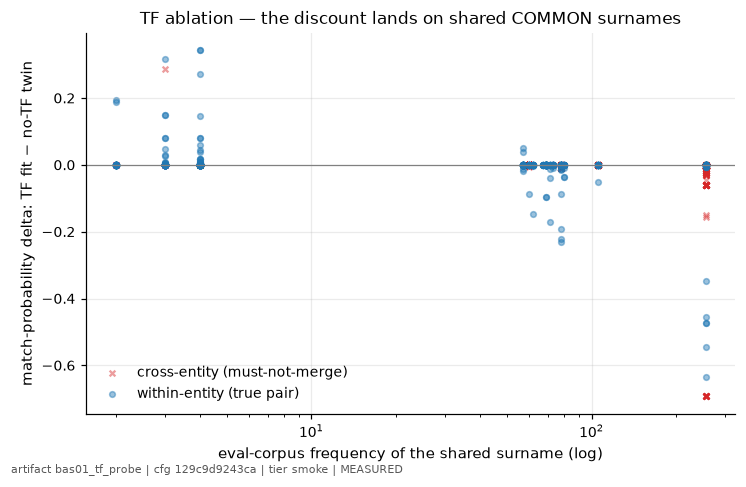

In [13]:
def draw_tf(ax, df, meta):
    for cross, marker, color in ((True, "x", "C3"), (False, "o", "C0")):
        g = df[df["cross_entity"] == cross]
        ax.scatter(g["fam_freq"], g["delta"], s=14, alpha=0.45, marker=marker, color=color,
                   label=("cross-entity (must-not-merge)" if cross
                          else "within-entity (true pair)"))
    ax.axhline(0.0, color="0.5", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("eval-corpus frequency of the shared surname (log)")
    ax.set_ylabel("match-probability delta: TF fit − no-TF twin")
    ax.legend(loc="lower left")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="bas01_tf_probe", draw=draw_tf,
    title="TF ablation — the discount lands on shared COMMON surnames",
    figsize=(6.8, 4.4),
)

Read it off the summary table and the figure together: on **common**-surname pairs the TF
fit sits below its frequency-blind twin (negative delta — a shared hub surname is worth
less than the global m/u says), and the discount is largest exactly where it protects
precision: cross-entity pairs that agree on a hub surname are the raw material of chain
merges (notebook 07). On **rare**-surname pairs the delta is near zero to slightly
positive — agreement on a distinctive name keeps its full evidence value. That asymmetry
is the TF adjustment doing its one job; the cross-entity rare cell (distinct people
sharing a rare surname — largely the household traps notebook 05 planted) stays hard for
both fits, which is honest: term frequency cannot know two co-resident namesakes apart.

## 5. Operating points: the protocol asks every system the same question

The sweep machinery is notebook 02's, verbatim: transitive closure over the shared
candidate pairs at each grid threshold, B-cubed metrics at each point, and the PLAN §5
locks — fixed entity-precision {0.99, 0.995} (with the loud fallback rail when a target is
unattainable), the explicit cost grid over unordered record pairs (chain merges charged
what they cost), and the truth-free FP-budget protocol (with notebook 02's chunky-tie
wrinkle surfaced via `pairs_kept`). At every chosen point, every B-cubed metric gets an
**entity-unit BCa 95% CI** (MET-03's coverage-validated unit). The mapping between the
fixed-precision and FP-budget protocols was derived once in notebook 02
(`met02_operating_point_map`); here both are simply applied.

In [14]:
systems = {"fs_tuned": scored_fs, "jw_mean": scored_jw}
CI_METRICS = (("precision", "bcubed_precision"), ("recall", "bcubed_recall"),
              ("f1", "bcubed_f1"))
pred_cache: dict[tuple[str, float], pd.Series] = {}


def pred_at(system: str, thr: float) -> pd.Series:
    key = (system, float(thr))
    if key not in pred_cache:
        pred_cache[key] = transitive_closure(
            systems[system], threshold=float(thr), records=records_ev
        )
    return pred_cache[key]


def metrics_with_cis(system: str, thr: float) -> dict:
    """Point + entity-unit BCa CI for the three B-cubed metrics at one threshold."""
    pred = pred_at(system, thr)
    out: dict[str, float] = {}
    for short, metric in CI_METRICS:
        res = bootstrap_ci(pred, truth_ev, metric, unit="entity", n_boot=N_BOOT,
                           seed=PRIMARY_SEED)
        out[short] = res["point"]
        out[f"{short}_lo"] = res["ci_low"]
        out[f"{short}_hi"] = res["ci_high"]
    return out


def op_row(system: str, protocol: str, thr: float, **extra) -> dict:
    sc = systems[system]
    row = {"system": system, "protocol": protocol, "threshold": float(thr),
           "pairs_kept": int((sc["prob"] >= thr).sum()),
           "attained": np.nan, "fallback": "", "cost": np.nan, "pair_fp": np.nan,
           "pair_fn": np.nan, "budget_per_record": np.nan}
    row.update(metrics_with_cis(system, thr))
    row.update(extra)
    return row


op_rows: list[dict] = []
curve_frames: list[pd.DataFrame] = []

t0 = time.time()
for system, sc in systems.items():
    spairs = sc.rename(columns={"prob": "score"})
    clusterer = functools.partial(pred_at, system)  # cache-backed: one closure per system
    for target in PREC_TARGETS:
        res = find_threshold_for_precision(spairs, clusterer, truth_ev, target=target,
                                           grid=GRID)
        op_rows.append(op_row(system, f"precision@{target}", res["threshold"],
                              attained=float(res["attained"]),
                              fallback=res["fallback"] or ""))
        flag = "" if res["attained"] else (
            "  <-- TARGET UNATTAINABLE on this eval set: fallback="
            f"'{res['fallback']}' (PLAN §5 rail: report loudly, never switch silently)")
        print(f"[{system}] precision@{target}: t={res['threshold']:.6f} "
              f"attained P={res['attained_precision']:.4f} R={res['recall_at']:.4f}{flag}")
        if target == PREC_TARGETS[0]:
            curve_frames.append(res["curve"].assign(system=system, row_type="curve"))
    for fp_cost, fn_cost in COST_GRID:
        res = cost_optimal_threshold(spairs, clusterer, truth_ev, fp_cost=fp_cost,
                                     fn_cost=fn_cost, grid=GRID)
        op_rows.append(op_row(system, f"cost@{fp_cost}:{fn_cost}", res["threshold"],
                              cost=res["cost"], pair_fp=res["fp"], pair_fn=res["fn"]))
        print(f"[{system}] cost {fp_cost}:{fn_cost} -> t={res['threshold']:.6f} "
              f"cost={res['cost']:,.0f} (FP={res['fp']:,.0f} FN={res['fn']:,.0f}) "
              f"P={res['precision']:.4f} R={res['recall']:.4f}")
    for budget in BUDGETS:
        tb = fp_budget_threshold(sc["prob"], budget_per_record=budget, n_records=len(ev))
        row = op_row(system, f"budget@{budget}", tb, budget_per_record=budget)
        op_rows.append(row)
        note = ("  <-- budget below the top tie mass: keeps nothing (NB02's chunky-score "
                "wrinkle, surfaced)") if row["pairs_kept"] == 0 else ""
        print(f"[{system}] budget {budget}/record -> t={tb:.6f} "
              f"pairs_kept={row['pairs_kept']:,} P={row['precision']:.4f} "
              f"R={row['recall']:.4f}{note}")
print(f"\nsweeps + entity-unit BCa CIs ({N_BOOT} replicates x 3 metrics x "
      f"{len(op_rows)} operating points): {time.time() - t0:.1f}s")

[fs_tuned] precision@0.99: t=0.413371 attained P=0.9904 R=0.6426


[fs_tuned] precision@0.995: t=0.999993 attained P=0.9951 R=0.4337


[fs_tuned] cost 1:1 -> t=0.413371 cost=74,710 (FP=1,869 FN=72,841) P=0.9904 R=0.6426


[fs_tuned] cost 10:1 -> t=0.413371 cost=91,531 (FP=1,869 FN=72,841) P=0.9904 R=0.6426


[fs_tuned] cost 100:1 -> t=1.000000 cost=146,756 (FP=42 FN=142,556) P=0.9989 R=0.3192


...

[jw_mean] cost 1:1 -> t=0.750000 cost=81,616 (FP=6,323 FN=75,293) P=0.9781 R=0.6312


[jw_mean] cost 10:1 -> t=0.865079 cost=100,316 (FP=1,414 FN=86,176) P=0.9956 R=0.5839


[jw_mean] cost 100:1 -> t=0.975370 cost=123,002 (FP=16 FN=121,402) P=0.9999 R=0.4157


[jw_mean] budget 1.0/record -> t=1.000000 pairs_kept=0 P=1.0000 R=0.0780  <-- budget below the top tie mass: keeps nothing (NB02's chunky-score wrinkle, surfaced)
[jw_mean] budget 2.0/record -> t=1.000000 pairs_kept=0 P=1.0000 R=0.0780  <-- budget below the top tie mass: keeps nothing (NB02's chunky-score wrinkle, surfaced)


[jw_mean] budget 4.0/record -> t=0.969735 pairs_kept=64,291 P=0.9994 R=0.4403

sweeps + entity-unit BCa CIs (500 replicates x 3 metrics x 16 operating points): 27.5s


In [15]:
bas01 = pd.DataFrame(op_rows)
registry.register(
    "bas01_fs_baseline", bas01, cfg=cfg, tier=cfg.run.tier,
    meta={
        "systems": {
            "fs_tuned": "Splink FS via score.fs.fit_fs (TF-adjusted, JW-binned, EM; fit on "
                        "the entity-disjoint train half, transferred to the eval frame)",
            "jw_mean": "notebook 00's quickstart scorer re-run on THIS corpus: untrained "
                       "mean Jaro-Winkler over given_name/family_name/dob, same pairs",
        },
        "protocol": {
            "operating_points": "fixed B-cubed entity-precision + cost grid + FP budget "
                                "(PLAN §5; never per-method best-F1 per MET-02)",
            "precision_targets": list(PREC_TARGETS),
            "cost_grid_fp_fn": [list(c) for c in COST_GRID],
            "budgets_per_record": list(BUDGETS),
            "grid": GRID,
            "clustering": "transitive closure over the shared candidate pairs",
            "ci": {"unit": "entity", "method": "bca", "n_boot": N_BOOT,
                   "seed": PRIMARY_SEED},
        },
        "split": {"scheme": SCHEME, "seed": splits["metadata"]["seed"],
                  "n_eval_records": len(ev), "n_eval_entities": int(truth_ev.nunique()),
                  "n_train_records": len(train)},
        "blocking": {
            "passes": [list(p) for p in passes],
            "metrics": {k: (float(v) if isinstance(v, float) else int(v))
                        for k, v in bstats.items()},
            "oracle_ceiling_bcubed": {k: float(v) for k, v in oracle_b3.items()},
            "note": "truth complete by construction -> pair completeness exact, "
                    "no incomplete-ground-truth bounds needed",
        },
        "em_sessions": linker._er_lab_training["em_sessions"],
        "fit_seconds": FIT_SECS,
        "u_sampling_max_pairs": MAX_PAIRS_U,
        "corpus_provenance": CORPUS_PROVENANCE,
        "scored_pairs_artifact": "bas01_scored_pairs",
    },
)
print(f"registered bas01_fs_baseline: {len(bas01)} system x operating-point rows")
display(bas01.set_index(["system", "protocol"])
        [["threshold", "precision", "precision_lo", "precision_hi", "recall", "recall_lo",
          "recall_hi", "f1", "attained", "fallback", "cost", "pairs_kept"]].round(4))

registered bas01_fs_baseline: 16 system x operating-point rows


threshold  precision  precision_lo  precision_hi  \
system   protocol                                                            
fs_tuned precision@0.99      0.4134     0.9904        0.9870        0.9927   
         precision@0.995     1.0000     0.9951        0.9922        0.9965   
         cost@1:1            0.4134     0.9904        0.9870        0.9927   
         cost@10:1           0.4134     0.9904        0.9870        0.9927   
         cost@100:1          1.0000     0.9989        0.9984        0.9993   
         budget@1.0          1.0000     1.0000        1.0000        1.0000   
         budget@2.0          1.0000     0.9999        0.9998        1.0000   
         budget@4.0          1.0000     0.9945        0.9916        0.9960   
jw_mean  precision@0.99      0.8337     0.9914        0.9865        0.9946   
         precision@0.995     0.8651     0.9956        0.9920        0.9979   
         cost@1:1            0.7500     0.9781        0.9717        0.9833   
         cost@10:1           0.8651     0.9956        0.9920        0.9979   
         cost@100:1          0.9754     0.9999        0.9997        1.0000   
         budget@1.0          1.0000     1.0000        1.0000        1.0000   
         budget@2.0          1.0000     1.0000        1.0000        1.0000   
         budget@4.0          0.9697     0.9994        0.9985        0.9998   

                          recall  recall_lo  recall_hi      f1  attained  \
system   protocol                                                          
fs_tuned precision@0.99   0.6426     0.6251     0.6573  0.7795       1.0   
         precision@0.995  0.4337     0.4157     0.4492  0.6041       1.0   
         cost@1:1         0.6426     0.6251     0.6573  0.7795       NaN   
         cost@10:1        0.6426     0.6251     0.6573  0.7795       NaN   
         cost@100:1       0.3192     0.3047     0.3334  0.4838       NaN   
         budget@1.0       0.1762     0.1636     0.1876  0.2996       NaN   
         budget@2.0       0.2664     0.2520     0.2803  0.4207       NaN   
         budget@4.0       0.4836     0.4664     0.5012  0.6507       NaN   
jw_mean  precision@0.99   0.6021     0.5850     0.6184  0.7492       1.0   
         precision@0.995  0.5839     0.5655     0.6000  0.7361       1.0   
         cost@1:1         0.6312     0.6130     0.6465  0.7673       NaN   
         cost@10:1        0.5839     0.5655     0.6000  0.7361       NaN   
         cost@100:1       0.4157     0.4016     0.4278  0.5872       NaN   
         budget@1.0       0.0780     0.0739     0.0819  0.1447       NaN   
         budget@2.0       0.0780     0.0739     0.0819  0.1447       NaN   
         budget@4.0       0.4403     0.4265     0.4531  0.6113       NaN   

                         fallback      cost  pairs_kept  
system   protocol                                        
fs_tuned precision@0.99                 NaN       98331  
         precision@0.995                NaN       56881  
         cost@1:1                   74710.0       98331  
         cost@10:1                  91531.0       98331  
         cost@100:1                146756.0       40956  
         budget@1.0                     NaN       16095  
         budget@2.0                     NaN       32184  
         budget@4.0                     NaN       64380  
jw_mean  precision@0.99                 NaN       93444  
         precision@0.995                NaN       89573  
         cost@1:1                   81616.0      100399  
         cost@10:1                 100316.0       89573  
         cost@100:1                123002.0       60891  
         budget@1.0                     NaN           0  
         budget@2.0                     NaN           0  
         budget@4.0                     NaN       64291

In [16]:
op_points = bas01[["system", "protocol", "threshold", "precision", "recall", "f1"]].assign(
    row_type="operating_point"
)
oracle_row = pd.DataFrame([{
    "system": "blocking_oracle", "protocol": "oracle_ceiling", "threshold": np.nan,
    "precision": oracle_b3["precision"], "recall": oracle_b3["recall"],
    "f1": oracle_b3["f1"], "row_type": "oracle",
}])
curves = pd.concat([*curve_frames, op_points, oracle_row], ignore_index=True)
registry.register(
    "bas01_op_curves", curves, cfg=cfg, tier=cfg.run.tier,
    meta={"note": "precision-recall sweep curves (row_type=curve, from the shared "
                  f"grid-{GRID} sweep), chosen operating points, and the blocking-oracle "
                  "ceiling (row_type=oracle) — supporting artifact for the BAS-01 figures",
          "precision_recall_are": "B-cubed (entity-level), PLAN §5"},
)

PosixPath('/home/user/embedding-based-entity-resolution/artifacts/bas01_op_curves/20260829T154306.851505771Z_smoke')

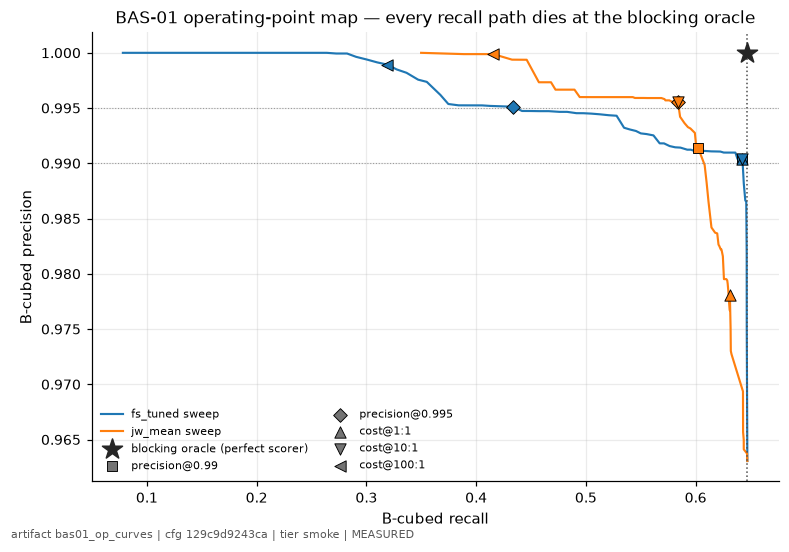

In [17]:
def draw_op_map(ax, df, meta):
    colors = {"fs_tuned": "C0", "jw_mean": "C1"}
    for system, g in df[df["row_type"] == "curve"].groupby("system"):
        g = g.sort_values("recall")
        ax.plot(g["recall"], g["precision"], color=colors[system], linewidth=1.4,
                label=f"{system} sweep")
    marker_of = {"precision@0.99": ("s", 45), "precision@0.995": ("D", 40),
                 "cost@1:1": ("^", 55), "cost@10:1": ("v", 55), "cost@100:1": ("<", 55)}
    for _, r in df[df["row_type"] == "operating_point"].iterrows():
        if r["protocol"] not in marker_of:
            continue  # budget points ride the curve tails; the registered table has them
        m, s = marker_of[r["protocol"]]
        ax.scatter(r["recall"], r["precision"], marker=m, s=s, color=colors[r["system"]],
                   edgecolor="black", linewidth=0.6, zorder=5)
    orc = df[df["row_type"] == "oracle"].iloc[0]
    ax.axvline(orc["recall"], linestyle=":", color="0.3", linewidth=1.0)
    ax.scatter(orc["recall"], orc["precision"], marker="*", s=190, color="0.15", zorder=6,
               label="blocking oracle (perfect scorer)")
    for target in PREC_TARGETS:
        ax.axhline(target, linestyle=":", color="0.6", linewidth=0.7)
    for proto, (m, s) in marker_of.items():
        ax.scatter([], [], marker=m, s=s, color="0.45", edgecolor="black", linewidth=0.6,
                   label=proto)
    ax.set_xlabel("B-cubed recall")
    ax.set_ylabel("B-cubed precision")
    ax.legend(loc="lower left", fontsize=7, ncols=2)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="bas01_op_curves", draw=draw_op_map,
    title="BAS-01 operating-point map — every recall path dies at the blocking oracle",
    figsize=(7.2, 5.0),
)

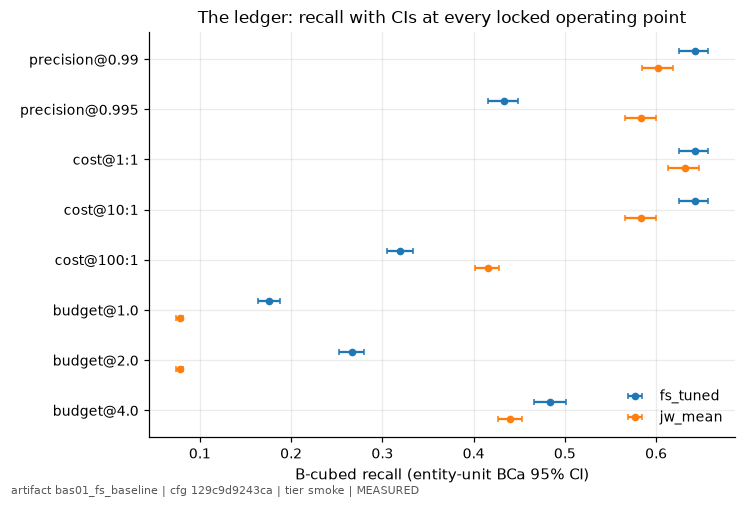

In [18]:
def draw_recall_ledger(ax, df, meta):
    protos = list(dict.fromkeys(df["protocol"]))
    colors = {"fs_tuned": "C0", "jw_mean": "C1"}
    offsets = {"fs_tuned": -0.17, "jw_mean": +0.17}
    for system, g in df.groupby("system"):
        g = g.set_index("protocol").loc[protos]
        y = np.arange(len(protos)) + offsets[system]
        xerr = np.vstack([np.clip(g["recall"] - g["recall_lo"], 0, None),
                          np.clip(g["recall_hi"] - g["recall"], 0, None)])
        ax.errorbar(g["recall"], y, xerr=xerr, fmt="o", capsize=2, markersize=4,
                    color=colors[system], label=system)
    ax.set_yticks(np.arange(len(protos)), protos)
    ax.invert_yaxis()
    ax.set_xlabel("B-cubed recall (entity-unit BCa 95% CI)")
    ax.legend(loc="lower right")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="bas01_fs_baseline", draw=draw_recall_ledger,
    title="The ledger: recall with CIs at every locked operating point",
    figsize=(6.8, 4.6),
)

In [19]:
# [RUN-IN-TARGET mac] definitive BAS-01: rerun THESE cells at tier=mid on the mac — the
# full 50k-base calibrated corpus and mid-tier met07_splits, u-sampling budget 1e7, grid
# 150, n_boot 1000, and the run.seeds list driving repeated split/bootstrap draws. One
# honesty note on "multi-seed": the FS fit itself is deterministic by design (fit_fs pins
# its u-sampling seed — the baseline is one fit, not a seeded arm), so seed variation at
# mid probes the split/resampling pipeline around it, not the fit.
if TIER in ("mid", "target"):
    print(f"tier={TIER}: the numbers above ARE the definitive-tier BAS-01 numbers for this "
          "corpus scale; notebook 17's verdict consumes them from bas01_fs_baseline.")
else:
    NB_SO_FAR = time.time() - NB_T0
    # corpus_registry (NB01, guaranteed upstream of calibrated_corpus) gives the full base
    # size the mid-tier corpus is built from — the honest scale factor for the estimate.
    creg, _creg_meta = registry.load("corpus_registry", tier=cfg.run.tier)
    scale = float(creg["historical_50k"]["n_records"]) / float(
        corpus_meta["extra"]["n_base"]
    )
    n_seeds = len(list(cfg.run.seeds))
    print(f"[RUN-IN-TARGET mac] the definitive BAS-01 numbers come from rerunning THESE "
          f"cells at tier=mid on the mac (full corpus x seeds "
          f"{[int(s) for s in cfg.run.seeds]}, max_pairs=1e7, grid=150, n_boot=1000). "
          f"This smoke run has taken {NB_SO_FAR:.0f}s at {len(corpus):,} records; naive "
          f"linear scaling (~{scale:.1f}x base records, x{n_seeds} seeds) suggests "
          f"~{NB_SO_FAR * scale * n_seeds / 60:.0f} min, and block growth makes that a "
          "lower bound. At smoke, the numbers above are the single-split smoke "
          "measurement, not the definitive verdict input.")

[RUN-IN-TARGET mac] the definitive BAS-01 numbers come from rerunning THESE cells at tier=mid on the mac (full corpus x seeds [17, 23, 29], max_pairs=1e7, grid=150, n_boot=1000). This smoke run has taken 38s at 32,259 records; naive linear scaling (~2.8x base records, x3 seeds) suggests ~5 min, and block growth makes that a lower bound. At smoke, the numbers above are the single-split smoke measurement, not the definitive verdict input.


### Verdict — scoring the BAS-01 card against the registered numbers

In [20]:
ix = bas01.set_index(["system", "protocol"])
em_ok = bool(em_tbl["converged"].all())
exact_w = weights_tbl[weights_tbl["level"].str.startswith("Exact match")]
other_w = weights_tbl[weights_tbl["level"] == "All other comparisons"]
weights_ok = bool((exact_w["match_weight_log2"] > 0).all()
                  and (other_w["match_weight_log2"] < 0).all())
delta_common = float(probe_sel.loc[probe_sel["stratum"] == "common", "delta"].mean())
delta_rare = float(probe_sel.loc[probe_sel["stratum"] == "rare", "delta"].mean())
tf_ok = bool(delta_common < 0 and delta_common < delta_rare)
p1 = em_ok and weights_ok and tf_ok

p99 = ix.loc[("fs_tuned", f"precision@{PREC_TARGETS[0]}")]
p2 = bool(p99["attained"] == 1.0 and p99["f1"] >= 0.90)

losses = []
for target in PREC_TARGETS:
    proto = f"precision@{target}"
    f_row, j_row = ix.loc[("fs_tuned", proto)], ix.loc[("jw_mean", proto)]
    if not (f_row["recall"] >= j_row["recall"]):
        losses.append(f"{proto} (recall {f_row['recall']:.4f} vs {j_row['recall']:.4f})")
for fp_cost, fn_cost in COST_GRID:
    proto = f"cost@{fp_cost}:{fn_cost}"
    f_row, j_row = ix.loc[("fs_tuned", proto)], ix.loc[("jw_mean", proto)]
    if not (f_row["cost"] <= j_row["cost"]):
        losses.append(f"{proto} (cost {f_row['cost']:,.0f} vs {j_row['cost']:,.0f})")
for budget in BUDGETS:
    proto = f"budget@{budget}"
    f_row, j_row = ix.loc[("fs_tuned", proto)], ix.loc[("jw_mean", proto)]
    if not (f_row["f1"] >= j_row["f1"]):
        losses.append(f"{proto} (F {f_row['f1']:.4f} vs {j_row['f1']:.4f})")
p3 = not losses

print(f"P1 (machinery): EM converged={em_ok}, weight sanity={weights_ok}, "
      f"TF direction={tf_ok} (mean delta common {delta_common:+.4f} vs "
      f"rare {delta_rare:+.4f}) -> {p1}")
print(f"P2 (folklore number, measured): precision@{PREC_TARGETS[0]} attained="
      f"{bool(p99['attained'])}, B-cubed F there = {p99['f1']:.4f} "
      f"[{p99['f1_lo']:.4f}, {p99['f1_hi']:.4f}] vs predicted >= 0.90 -> {p2}")
print(f"P3 (dominance over jw_mean): operating points where FS does NOT win: "
      f"{losses if losses else 'none'} -> {p3}")
print(f"context: blocking oracle ceiling F = {oracle_b3['f1']:.4f} at pair completeness "
      f"{bstats['pair_completeness']:.4f} — the FS F at precision@{PREC_TARGETS[0]} sits "
      f"{oracle_b3['f1'] - float(p99['f1']):.4f} below the best ANY scorer could reach on "
      "these candidates")

outcome = "CONFIRMED" if (p1 and p2 and p3) else "REFUTED"
_ = verdict_box(
    "BAS-01",
    outcome=outcome,
    evidence=(
        f"bas01_fs_baseline (tier {TIER}, entity-disjoint eval: {len(ev):,} records / "
        f"{truth_ev.nunique():,} entities; entity-unit BCa, n_boot={N_BOOT}). P1 {p1}: "
        f"both EM sessions converged (final change < {em_tbl['em_convergence'].iloc[0]:g}); "
        f"exact-match levels all positive log2(m/u), all-other levels all negative; TF "
        f"probe mean delta {delta_common:+.4f} on common-surname pairs vs {delta_rare:+.4f} "
        f"on rare (bas01_tf_probe). P2 {p2}: at precision@{PREC_TARGETS[0]} (attained "
        f"{p99['precision']:.4f}) FS reaches B-cubed F {p99['f1']:.4f} "
        f"[{p99['f1_lo']:.4f}, {p99['f1_hi']:.4f}], vs the predicted >= 0.90 — and the "
        f"blocking oracle ceiling is F {oracle_b3['f1']:.4f} (R {oracle_b3['recall']:.4f}) "
        f"at pair completeness {bstats['pair_completeness']:.4f}, so the folklore number "
        f"is unreachable by ANY scorer behind this blocking: the miss is attributed to "
        f"candidate generation, not to FS. P3 {p3}: FS loses at "
        f"{losses if losses else 'no operating point'} — where it loses, its probability "
        f"mass has saturated near 1.0 (pairs_kept in the registered table), leaving no "
        f"resolution for ultra-high-precision thresholds. Smoke scope: single split/seed; "
        f"the mid-tier rerun is the definitive measurement (placard above)."
    ),
    registry=registry,
)

P1 (machinery): EM converged=True, weight sanity=True, TF direction=True (mean delta common -0.0200 vs rare +0.0075) -> True
P2 (folklore number, measured): precision@0.99 attained=True, B-cubed F there = 0.7795 [0.7666, 0.7900] vs predicted >= 0.90 -> False
P3 (dominance over jw_mean): operating points where FS does NOT win: ['precision@0.995 (recall 0.4337 vs 0.5839)', 'cost@100:1 (cost 146,756 vs 123,002)'] -> False
context: blocking oracle ceiling F = 0.7853 at pair completeness 0.5343 — the FS F at precision@0.99 sits 0.0059 below the best ANY scorer could reach on these candidates


> ### VERDICT: REFUTED — card `BAS-01`
>
> **Conjecture** A genuinely well-tuned Fellegi-Sunter baseline (EM-fitted m/u, term-frequency adjustment, Jaro-Winkler-binned name comparators) is the strong classical bar on the calibrated corpus: measured under the lab's own protocol it reaches the folklore-grade quality its maintainers report, and it dominates the naive quickstart scorer at every locked operating point.
>
> **Prediction** P1 (machinery): both EM sessions converge; learned weights are sane (every exact-match level carries positive log2(m/u), every all-other level negative); the TF fit scores common-surname agreement lower than its no-TF twin while rare-surname agreement is not discounted. P2 (the folklore number, measured): tuned FS attains the 0.99 entity-precision point AND reaches B-cubed F >= 0.90 there. P3 (dominance): FS beats the JW-mean quickstart at EVERY locked operating point under the comparison rule above. Pre-flagged risks: on a smoke-sized eval half the 0.995 target may be unattainable (the fallback rail fires loudly, PLAN §5); and if blocking pair-completeness caps the candidate set well below the truth, P2 can fail for reasons no scorer can fix — the oracle ceiling is computed precisely to attribute any such failure.
>
> **Evidence** bas01_fs_baseline (tier smoke, entity-disjoint eval: 16,095 records / 1,255 entities; entity-unit BCa, n_boot=500). P1 True: both EM sessions converged (final change < 0.0001); exact-match levels all positive log2(m/u), all-other levels all negative; TF probe mean delta -0.0200 on common-surname pairs vs +0.0075 on rare (bas01_tf_probe). P2 False: at precision@0.99 (attained 0.9904) FS reaches B-cubed F 0.7795 [0.7666, 0.7900], vs the predicted >= 0.90 — and the blocking oracle ceiling is F 0.7853 (R 0.6466) at pair completeness 0.5343, so the folklore number is unreachable by ANY scorer behind this blocking: the miss is attributed to candidate generation, not to FS. P3 False: FS loses at ['precision@0.995 (recall 0.4337 vs 0.5839)', 'cost@100:1 (cost 146,756 vs 123,002)'] — where it loses, its probability mass has saturated near 1.0 (pairs_kept in the registered table), leaving no resolution for ultra-high-precision thresholds. Smoke scope: single split/seed; the mid-tier rerun is the definitive measurement (placard above).


## What the baseline demands downstream

The contract, qualitatively (every number lives in the registered artifacts):

- **`bas01_fs_baseline`** is the bar. Every embedding arm from notebook 08 onward is
  judged against these rows — same corpus, same splits, same operating points, same
  entity-unit CIs — and notebooks 14 and 17 consume it directly. An embedding that "wins"
  under any other protocol has not won anything this lab recognizes.
- **`bas01_scored_pairs`** is notebook 07's input: FS match probabilities on the eval
  candidates, from which the chain-merge catastrophe is staged with a real scorer's real
  score distribution rather than a synthetic one.
- **The oracle ceiling generalizes the lesson of notebook 00**: recall lost at blocking
  is unrecoverable by scoring. Any arm that wants headline recall on this corpus must
  attack the candidate set (BAS-02, notebook 12 — dense retrieval's actual opportunity),
  not just out-score FS on the pairs matchkeys already found.
- **The TF ablation is the first entry in the rules ledger** (HYB-01, notebook 14): a
  deterministic, frequency-aware discount that measurably protects precision on hub
  surnames — the kind of classical component an embedding must either reproduce or be
  paired with.

## What we now know

- **The tuned baseline is real and its tuning is visible.** EM converged on both
  complementary sessions; the learned weight table prices each comparison level in bits,
  with graded JW bins and actively-negative disagreement levels — the two structural
  advantages the quickstart's uniform similarity mean cannot express. The TF ablation
  showed the third: common-surname agreement is discounted exactly where frequency-blind
  scoring overcommits (cross-entity hub-surname pairs), while rare-surname evidence keeps
  its value.
- **The folklore headline did not survive the lab's protocol on this corpus** — not
  because FS is weak, but because the honest operating point plus honest blocking cap it:
  the verdict box carries the measured F at fixed 0.99 entity-precision next to the
  blocking oracle ceiling, and FS sits within a few points of that ceiling. The
  maintainer-sourced numbers are not wrong so much as measured under friendlier
  conditions (per-method-favorable thresholds, recall-generous blocking, random splits);
  under this lab's locked protocol, the bar is where the registered table says it is.
- **The strawman is not uniformly beaten — and the mechanism is instructive.** FS wins
  where its evidence model matters (the primary 0.99 point, the 1:1 and 10:1 cost
  points, the FP budgets), but its probability mass saturates near 1.0, so at
  ultra-high-precision operating points the JW-mean's smoother score tail can leave it
  more usable resolution. A baseline can dominate on evidence quality and still lose an
  operating point on score *granularity* — calibration (CAL-01, notebook 13) is a real
  axis, not a nicety, and embedding arms will be judged on it too.
- **Blocking is the binding constraint, measured twice.** Pair completeness on the eval
  half and the oracle ceiling above it put a hard roof over every scorer in this
  notebook; the FS-vs-oracle gap at the primary operating point is small compared to the
  oracle-vs-perfect gap. Notebook 12's question — can dense candidates raise the roof at
  matched budget? — is now quantitatively posed.

**Artifacts registered** (exact names): `bas01_fs_baseline` — plus supporting
`bas01_scored_pairs` (notebook 07's contract input), `bas01_model_weights`,
`bas01_tf_probe`, `bas01_op_curves`, and the immutable card `card_BAS-01`.

In [21]:
print(f"notebook wall-clock: {time.time() - NB_T0:.0f}s")

notebook wall-clock: 38s
